# Байесовский подход в анализе данных
## Задание 2

**Правила:**

* Дедлайны см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Выполненную работу нужно отправить телеграм-боту. Для начала работы с ботом каждый раз отправляйте `/start`. Дождитесь подтверждения от бота, что он принял файл. Если подтверждения нет, то что-то не так. **Работы, присланные иным способом, не принимаются.**
* Дедлайны см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Прислать нужно **ноутбук в формате `ipynb`**.
* Следите за размером файлов. **Бот не может принимать файлы весом более 20 Мб.** Если файл получается больше, заранее разделите его на несколько.
* Выполнять задание необходимо полностью самостоятельно. **При обнаружении списывания все участники списывания получат штраф.**
* Решения, размещенные на каких-либо интернет-ресурсах, не принимаются. Кроме того, публикация решения в открытом доступе может быть приравнена к предоставлении возможности списать.
* Для выполнения задания используйте этот ноутбук в качестве основы, ничего не удаляя из него. Можно добавлять необходимое количество ячеек.
* Комментарии к решению пишите в markdown-ячейках.
* Выполнение задания (ход решения, выводы и пр.) должно быть осуществлено на русском языке.
* Решение проверяется системой ИИ-проверки <a href="https://thetahat.ru/"><img src="https://miptstats.github.io/theta_grader_small.png" style="display: inline; vertical-align: middle;"></a> **ThetaGrader**. Результат проверки валидируется и исправляется человеком, после чего комментарии отправляются студентам.
* Если код будет не понятен проверяющему, оценка может быть снижена.
* Никакой код из данного задания при проверке запускаться не будет. *Если код студента не выполнен, недописан и т.д., то он не оценивается.*
* В каждой задаче не забывайте делать **пояснения и выводы**.
* **Код из рассказанных на занятиях ноутбуков** можно использовать без ограничений.


**Правила оформления теоретических задач:**

* Решения необходимо прислать одним из следующих способов:
  * фотографией в правильной ориентации, где все четко видно, а почерк разборчив,
    * отправив ее как файл боту вместе с ноутбуком *или*
    * вставив ее в ноутбук посредством `Edit -> Insert Image` (<font color="red">фото, вставленные ссылкой, не принимаются</font>);
  * в виде $LaTeX$ в markdown-ячейках.
* Решения не проверяются, если какое-то требование не выполнено. Особенно внимательно все проверьте в случае выбора второго пункта (вставки фото в ноутбук). <font color="red"><b>Неправильно вставленные фотографии могут не передаться при отправке.</b></font> Для проверки попробуйте переместить `ipynb` в другую папку и открыть его там.
* В решениях поясняйте, чем вы пользуетесь, хотя бы кратко. Например, если пользуетесь независимостью, то достаточно подписи вида "*X и Y незав.*"
* Решение, в котором есть только ответ, и отсутствуют вычисления, оценивается в 0 баллов.

**Баллы за задание:**

* Задача 1 &mdash;  80 баллов
* Задача 2 &mdash;  40 баллов
* Задача 3 &mdash;  50 баллов

In [169]:
# Bot check

# HW_ID: ds_bayes2
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: not final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную.
# Никакие значения в этой ячейке не влияют на факт сдачи работы.

__________________
### Задача 1.

В данной задаче вам нужно расписать вариационный байесовский вывод для линейной регрессии с регуляризацией. Отличие от рассматриваемых нами ранее задач заключается в рассмотрении априорных распределений на параметры, отвечающую за дисперсию. Процедуру, которую вы получите, реализует класс `sklearn.linear_model.BayesianRidge`.
	
Рассмотрим постановку задачи линейной регрессии. Пусть $Y = X\theta + \varepsilon$, где $\varepsilon \sim \mathcal{N}(0, \beta^{-1}I_n)$. Таким образом,
$$Y|\theta \sim \mathcal{N}(X\theta, \beta^{-1}I_n).$$
	
Введем априорное распределение на $\theta$ ($L_2$-регуляризатор)
$$\theta \sim \mathcal{N}(0, \alpha^{-1}I_d).$$
	
Считая $\alpha$ и $\beta$ гиперпараметрами, мы получали точное аналитическое решение (апостериорное распределение $\theta$), а также процедуру выбора значений гиперпараметров $\alpha$ и $\beta$ методом максимальной обоснованности. В данной задаче будем считать $\alpha$ и $\beta$ случайными параметрами, для которых заданы априорные распределения
$$\alpha \sim \Gamma(u_0, v_0),\ \ \beta \sim \Gamma(c_0, d_0),$$
причем $\alpha$ и $\beta$ не зависят от $\theta$ и $Y$. Задача заключается в том, чтобы найти апостериорное распределение на $(\theta, \alpha, \beta)$.

**1.** Выпишите $f(y, t, a, b)$ &mdash; совместное распределение $(Y, \theta, \alpha, \beta)$. Выпишите также $\log f(y, t, a, b)$.

**2.** В рамках вариационного байесовского вывода рассмотрим такое семейство $\mathcal{Q}$, для которого $\theta, \alpha, \beta$ независимы. Распишите, из каких распределений состоит семейство $\mathcal{Q}$.

**3.** Распишите первый шаг вариационного байесовского вывода по формуле 
		$$\log q_1(t) \propto \mathsf{E}_{23} \log f(Y, t, \alpha, \beta),$$
		сведя выражение к квадратичной форме по $t$. Какое распределение получается? Обозначьте его параметры не встречавшимися ранее буквами. В ответе должны остаться математические ожидания $\mathsf{E}_2$ и $\mathsf{E}_3$.

**4.** Сделайте аналогичную операцию для второго и третьего шага.

**5.** Распишите формулу для ELBO, то есть $$\mathcal{L}(q) = \mathsf{E}_{123} \log f(Y, \theta, \alpha, \beta) - \mathsf{E}_{1} \log q_1(\theta) - \mathsf{E}_{2} \log q_2(\alpha) - \mathsf{E}_{3} \log q_3(\beta).$$
		В ответе должны остаться математические ожидания $\mathsf{E}_1$, $\mathsf{E}_2$ и $\mathsf{E}_3$.

**6.** Вычислите все математические ожидания, полученные на предыдущих шагах.

**7.** Опишите кратко получаемую итерационную процедуру.

**8.** Пусть $x_{new}$ &mdash; новый объект, а $y_{new} = x_{new}^T\theta + \varepsilon_{new}$. Какое распределение имеет $y_{new} | (Y, \beta)$? Какой интеграл необходимо вычислить для получения предсказательного распределения $y_{new} | Y$? Такой интеграл аналитически не берется. Как можно решить проблему?

$\square$

## СМОТРЕТЬ В ПДФ

$\blacksquare$

__________________
### Задача 2.

Реализуйте процедуру, полученную в пункте 7 задачи 1. 

*Указания.*
1. Придерживайтесь sklearn-подобного интерфейса.
2. Сохраняйте значения всех параметров после каждой итерации, то есть в итоге должна получиться трассировка для каждого параметра.
3. До начала работы метода сгенерируйте случайное начальное приближение параметров распределений $\alpha$ и $\beta$. Используя эти приближения уже можно сделать первый шаг метода.

In [170]:
import numpy as np
import scipy.stats as sps
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from scipy.special import digamma, gammaln, gamma
from scipy.stats import rv_continuous
import time

In [171]:
def our_gamma(alpha=1, beta=1):
    return sps.gamma(alpha, scale=1/beta)

In [172]:
class MyBayesianRidge:
    def __init__(
        self, n, d, Y, X, v0=12, u0=1, d0=2, c0=1, s=2, p=1, l=2, k=1, random_state=None
    ):
        self.n = n
        self.d = d
        self.Y = Y
        self.X = X
        self.v0 = v0
        self.u0 = u0
        self.d0 = d0
        self.c0 = c0
        self.s = s
        self.p = p
        self.l = l
        self.k = k
        self.mu = np.zeros(self.d)
        self.Lambda = np.eye(self.d)
        self.rng = np.random.RandomState(random_state)

        self.q1 = sps.multivariate_normal(self.mu, self.Lambda)
        self.q2 = our_gamma(self.p, self.s)
        self.q3 = our_gamma(self.k, self.l)

        self.E_alpha = self.rng.rand() + 0.5
        self.E_beta = self.rng.rand() + 0.5
        self.Elog_alpha = digamma(self.p) - np.log(self.s)
        self.Elog_beta = digamma(self.l) - np.log(self.k)

        self.E_13 = 0
        self.E_12 = 0
        self.E_1_from_normal = 0

        self.history_ELBO = []
        self.history_theta = []
        self.history_alpha = [self.E_alpha]
        self.history_beta = [self.E_beta]

    def _calculate_Lq(self):
        result = (
            self.n / 2 * self.Elog_beta
            - 1 / 2 * self.E_13
            + self.d / 2 * self.Elog_alpha
            - 1 / 2 * self.E_12
            + (self.v0 - 1) * self.Elog_alpha
            - self.u0 * self.E_alpha
            + (self.d0 - 1) * self.Elog_beta
            - self.c0 * self.E_beta
            + 1 / 2 * self.E_1_from_normal
            - (self.s - 1) * self.Elog_alpha
            + self.p * self.E_alpha
            - (self.l - 1) * self.Elog_beta
            + self.k * self.E_beta
        )

        return result

    def _make_step_1(self):
        mu = np.linalg.inv(
            self.E_alpha * np.eye(self.d)
            + self.E_beta * self.X.T @ self.X
            + 1e-6 * np.eye(self.d)
        ) @ (self.E_beta * self.X.T @ self.Y)
        Lambda = np.linalg.inv(
            self.E_alpha * np.eye(self.d)
            + self.E_beta * self.X.T @ self.X
            + 1e-6 * np.eye(self.d)
        )

        self.q1 = sps.multivariate_normal(mu, Lambda)

        # Пересчет мат. ожиданий
        self.E_theta = mu
        self.E_thetaT_theta = np.trace(Lambda) + mu.T @ mu
        self.Y_Xtheta_x2 = (
            self.Y.T @ self.Y
            - 2 * self.Y.T @ self.X @ mu
            + np.trace(self.X.T @ self.X @ Lambda)
            + mu.T @ self.X.T @ self.X @ mu
        )

        # Сохраняем историю theta
        self.history_theta.append(self.E_theta.ravel().copy())

    def _make_step_2(self):
        self.p = self.u0 + 1 / 2 * self.E_thetaT_theta
        self.s = self.d / 2 + self.v0
        self.q2 = our_gamma(self.p, self.s)

        # Пересчет мат. ожиданий
        self.E_alpha = self.s / self.p
        self.Elog_alpha = digamma(self.p) - np.log(self.s)

        # Сохраняем историю alpha
        self.history_alpha.append(self.E_alpha.item())

    def _make_step_3(self):
        self.k = self.c0 + self.Y_Xtheta_x2
        self.l = self.n / 2 + self.d0

        self.q3 = our_gamma(self.k, self.l)

        # Пересчет мат. ожиданий
        self.E_beta = self.l / self.k
        self.Elog_beta = digamma(self.l) - np.log(self.k)

        # Сохраняем историю beta
        self.history_beta.append(self.E_beta.item())

    def _prepare_expectations_for_Lq(self):
        self.E_13 = self.E_beta * self.Y_Xtheta_x2
        self.E_12 = self.E_alpha * self.E_thetaT_theta
        self.E_1_from_normal = self.d

    def _make_step_4(self):
        Lq = self._calculate_Lq()
        self.history_ELBO.append(Lq.item())
        return Lq

    def fit(self, tol=1e-6, max_iter=1000):
        L_cur, L_prev = -(2**32), -(2**33)
        iter_count = 0
        while L_cur - L_prev > tol and iter_count < max_iter:
            self._make_step_1()
            self._make_step_2()
            self._make_step_3()
            self._prepare_expectations_for_Lq()
            L_prev = L_cur
            L_cur = self._make_step_4()
            iter_count += 1

        return (
            L_cur,
            self.q1,
            self.q2,
            self.q3,
            self.history_theta,
            self.history_alpha,
            self.history_beta,
        )

    def plot_history(self):
        # Количество графиков: ELBO, alpha, beta, theta
        n_plots = 4
        n_cols = 2
        n_rows = (n_plots + 1) // 2

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
        axes = axes.flatten()

        # --- ELBO ---
        axes[0].plot(
            self.history_ELBO,
            color="royalblue",
            linewidth=2,
            marker="o",
            markersize=4,
            alpha=0.8,
        )
        axes[0].set_ylabel("L(q)", color="royalblue", fontsize=12)
        axes[0].tick_params(axis="y", labelcolor="royalblue", labelsize=10)
        axes[0].set_title("Эволюция ELBO", fontsize=14)
        axes[0].grid(True, linestyle="--", alpha=0.5)

        # --- E[alpha] ---
        axes[1].plot(
            self.history_alpha,
            color="seagreen",
            linewidth=2,
            marker="o",
            markersize=4,
            alpha=0.8,
        )
        axes[1].set_ylabel("E[alpha]", color="seagreen", fontsize=12)
        axes[1].tick_params(axis="y", labelcolor="seagreen", labelsize=10)
        axes[1].set_title("Эволюция E[alpha]", fontsize=14)
        axes[1].grid(True, linestyle="--", alpha=0.5)

        # --- E[beta] ---
        axes[2].plot(
            self.history_beta,
            color="crimson",
            linewidth=2,
            marker="o",
            markersize=4,
            alpha=0.8,
        )
        axes[2].set_ylabel("E[beta]", color="crimson", fontsize=12)
        axes[2].set_xlabel("Iteration", fontsize=12)
        axes[2].tick_params(axis="y", labelcolor="crimson", labelsize=10)
        axes[2].set_title("Эволюция E[beta]", fontsize=14)
        axes[2].grid(True, linestyle="--", alpha=0.5)

        # --- Theta (все компоненты) ---
        thetas = np.array(self.history_theta)  # shape = (n_iter, d)
        for j in range(thetas.shape[1]):
            axes[3].plot(
                thetas[:, j],
                linewidth=2,
                marker="o",
                markersize=4,
                alpha=0.8,
                label=f"Theta[{j}]",
            )
        axes[3].set_ylabel("E[Theta]", fontsize=12)
        axes[3].set_xlabel("Iteration", fontsize=12)
        axes[3].set_title("Эволюция Theta (все компоненты)", fontsize=14)
        axes[3].grid(True, linestyle="--", alpha=0.5)
        axes[3].legend()

        # Если графиков меньше ячеек, отключаем лишние оси
        for ax in axes[n_plots:]:
            ax.set_visible(False)

        plt.tight_layout()
        plt.show()

    def predict(self, X_new):
        if not hasattr(self, "E_theta"):
            raise ValueError("Сначала вызовите fit для обучения модели.")
        y_pred = X_new @ self.E_theta
        return np.asarray(y_pred).reshape(-1)

Протестируйте работу метода на двух примерах:
* сгенерированные данные, один признак;
* датасет `bikes_rent.csv` из предыдущего домашнего задания.

В каждом случае визуализируйте динамику ELBO с ростом числа итераций, а также динамику математических ожиданий для $\theta$, $\alpha$ и $\beta$. Кривые для $\theta$ стоит рисовать на одном графике, все остальные &mdash; на отдельных.

1. Сгенерированные данные.

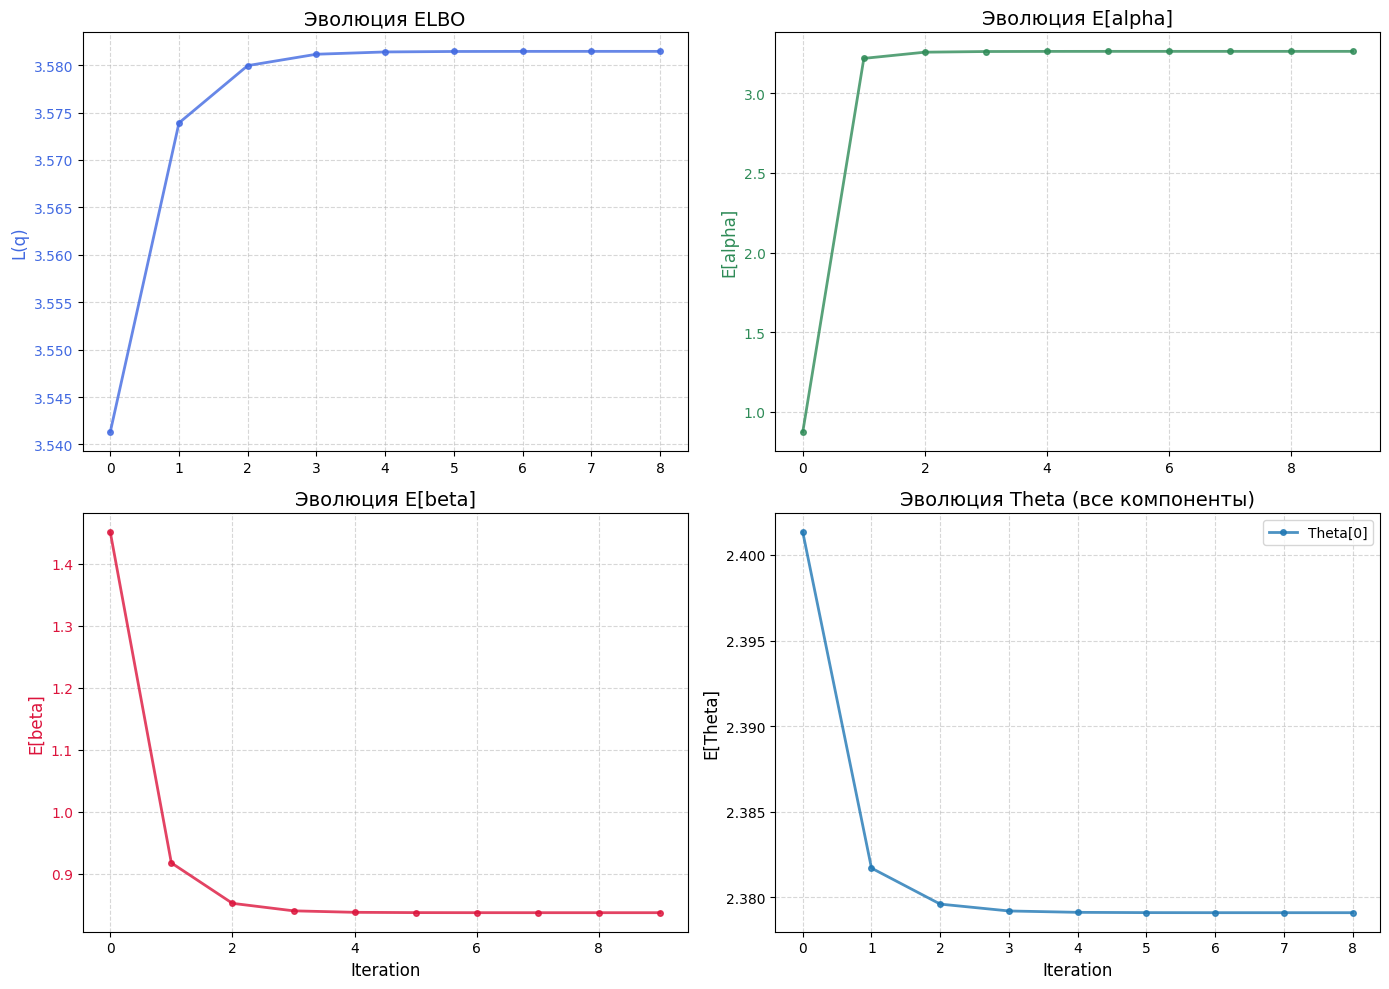

In [173]:
n_train = 10
n_test = 20

# X.shape = (n_samples, n_features)
X_train = np.linspace(0, 10, n_train).reshape(-1, 1)  # (50,1)
theta_true = np.array([2.5])

# Y.shape = (n_samples,1)
Y_train = X_train @ theta_true.reshape(-1, 1) + np.random.randn(n_train, 1) * 1.0

X_test = np.linspace(0, 10, n_test).reshape(-1, 1)
Y_test_true = X_test @ theta_true.reshape(-1, 1)  # чистая прямая для проверки

model = MyBayesianRidge(n=n_train, d=1, Y=Y_train, X=X_train, random_state=42)
model.fit(max_iter=50)
model.plot_history()

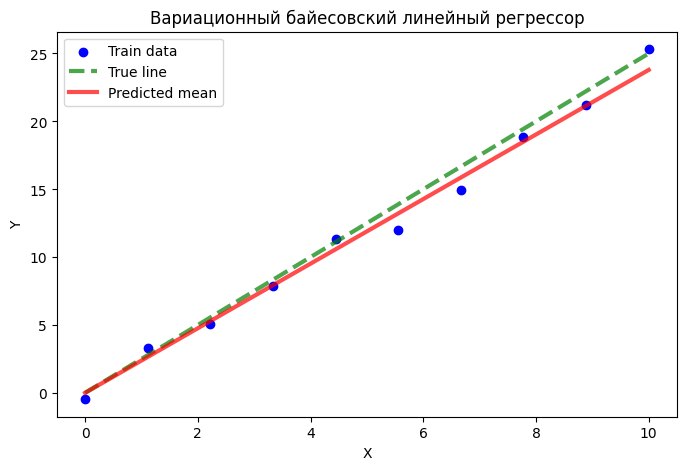

In [174]:
Y_pred = model.predict(X_test)

plt.figure(figsize=(8, 5))
plt.scatter(X_train, Y_train, color='blue', label='Train data')
plt.plot(X_test, Y_test_true, color='green', label='True line', linestyle='--', linewidth=3, alpha=0.7)
plt.plot(X_test, Y_pred, color='red', label='Predicted mean', linewidth=3, alpha=0.7)
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.title('Вариационный байесовский линейный регрессор')
plt.show()

2. `bikes_rent.csv`

In [175]:
bikes_df = pd.read_csv("bikes_rent.csv")


In [176]:
corr = bikes_df.corr(numeric_only=True)

threshold = 0.9
corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
corr_pairs.columns = ["feature_1", "feature_2", "correlation"]
high_corr = corr_pairs[abs(corr_pairs["correlation"]) > threshold]
print(high_corr)

         feature_1      feature_2  correlation
63            temp          atemp     0.991702
75  windspeed(mph)  windspeed(ms)     1.000000


In [177]:
bikes_df = bikes_df.drop(columns=["atemp", "windspeed(ms)"])

In [178]:
X = bikes_df.drop(columns=["cnt"])
y = bikes_df["cnt"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [179]:
categorical = ["season", "yr", "mnth", "holiday", "weekday", "workingday", "weathersit"]
numerical = [col for col in X_train.columns if col not in categorical]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore", drop="first"),
            categorical,
        ),
        ("num", "passthrough", numerical),
    ]
)

X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

In [180]:
n, d = X_train.shape

In [181]:
def random_hyperparams(random_state=None):
    rng = np.random.RandomState(random_state)
    
    params = {
        "v0": rng.uniform(1, 20),
        "u0": rng.uniform(0.1, 5),
        "d0": rng.uniform(1, 10),
        "c0": rng.uniform(0.1, 5),
        "s": rng.uniform(0.5, 5),
        "p": rng.uniform(0.5, 5),
        "l": rng.uniform(0.5, 5),
        "k": rng.uniform(0.5, 5),
    }
    return params

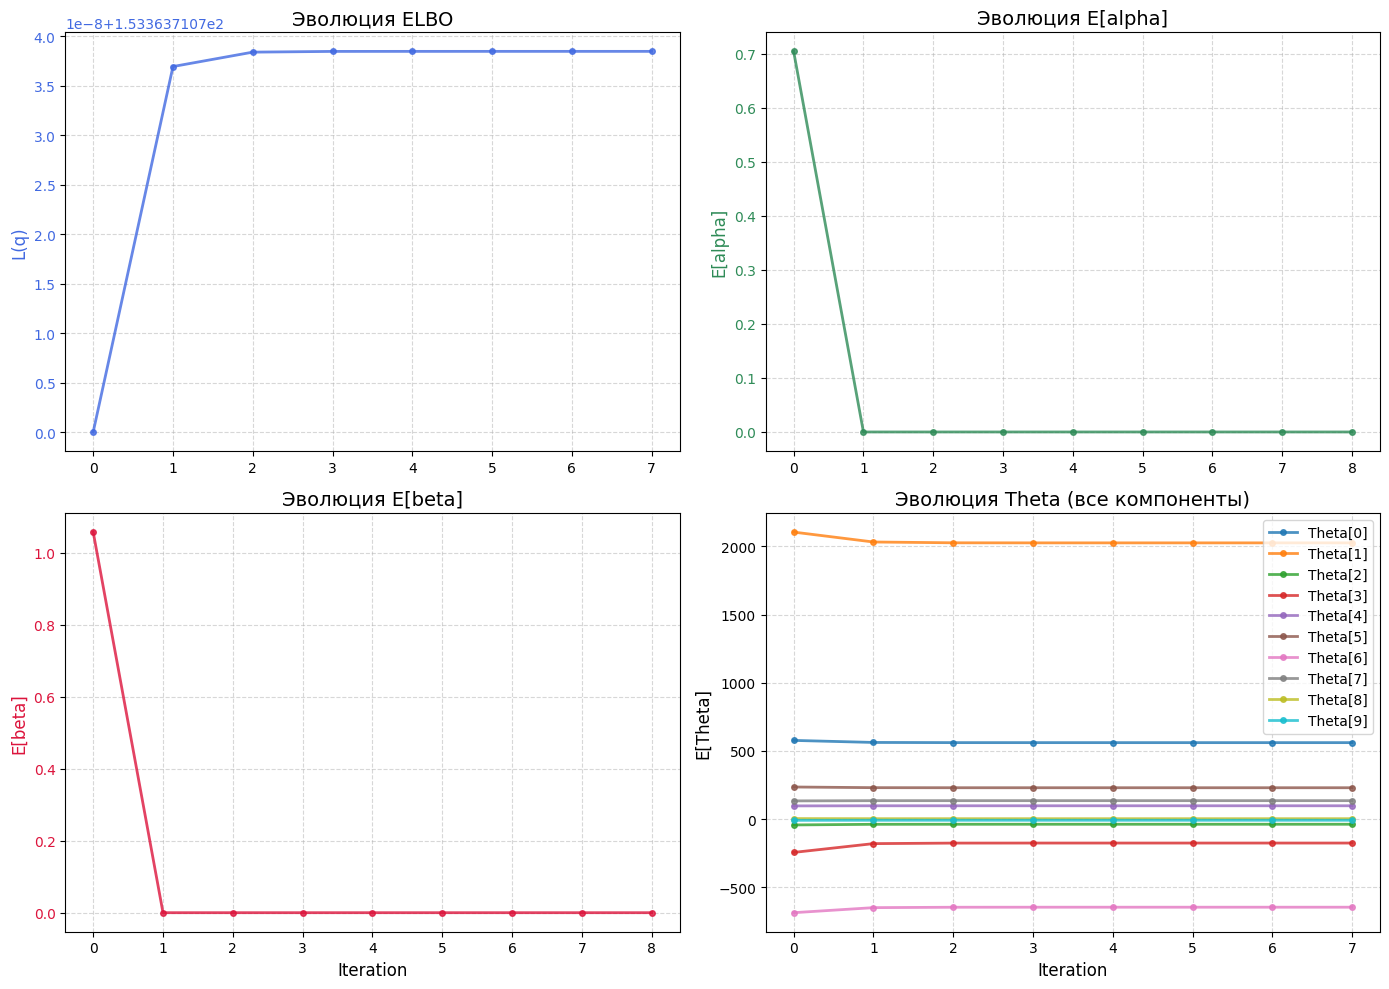

In [182]:
model = MyBayesianRidge(n=n, d=d, Y=y_train, X=X_train, **random_hyperparams())
model.fit(max_iter=100, tol=1e-30)

model.plot_history()

In [183]:
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}")
print(f"MAE:  {mae:.2f}")
print(f"R²:   {r2:.3f}")

MSE:  801482.26
RMSE: 895.26
MAPE: 1.64
MAE:  658.88
R²:   0.800


Запустите модель повторно из другого начального приближения. Поменялись ли результаты?

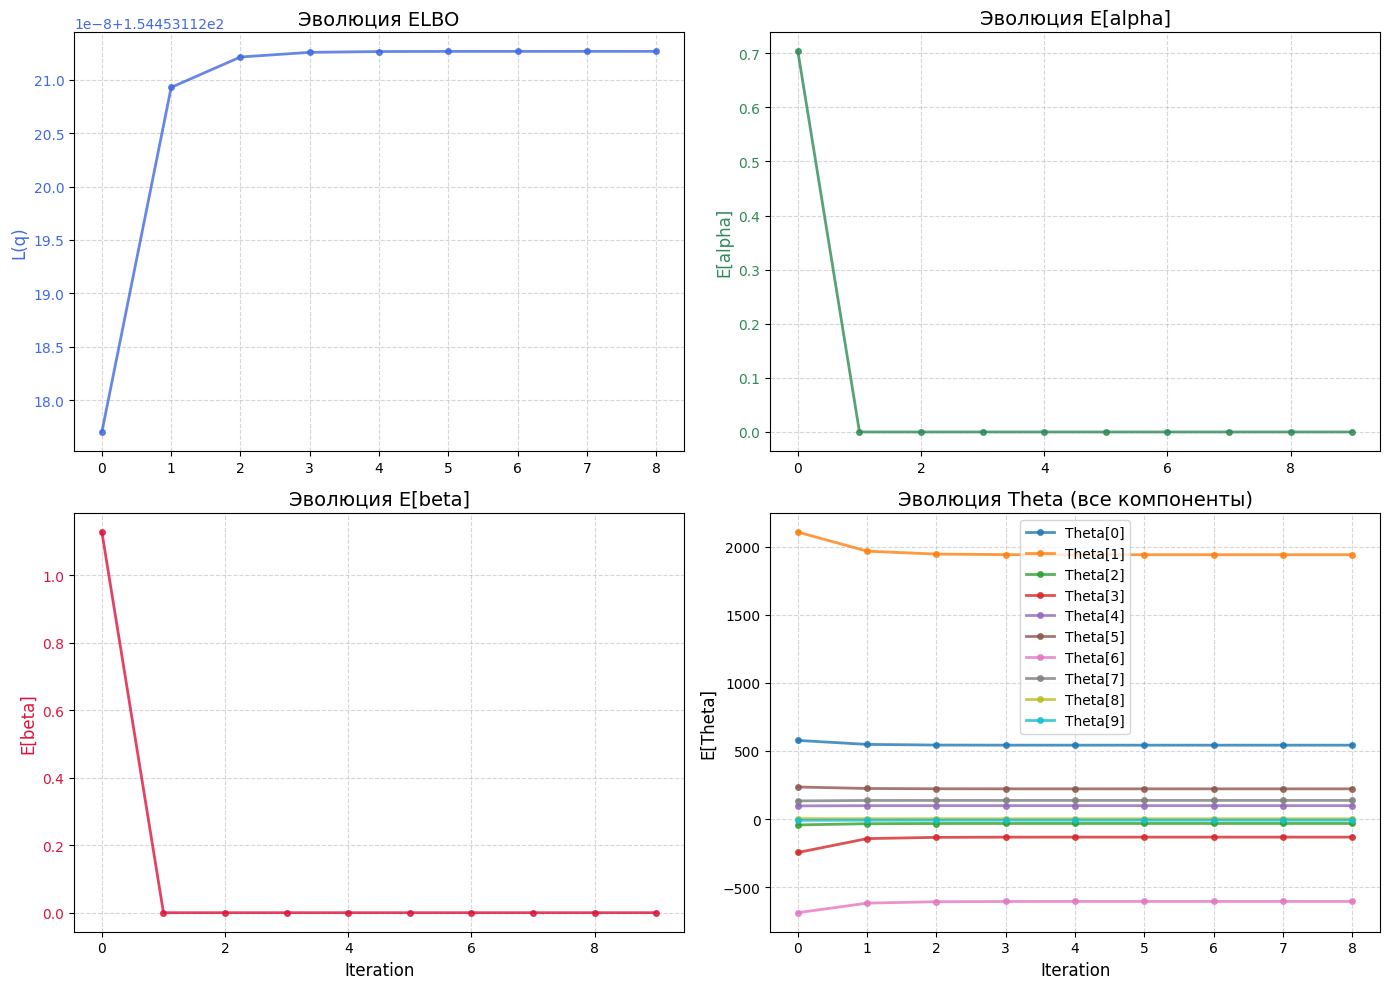

In [184]:
model = MyBayesianRidge(n=n, d=d, Y=y_train, X=X_train, **random_hyperparams())
model.fit(max_iter=100, tol=1e-30)

model.plot_history()

In [185]:
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}")
print(f"MAE:  {mae:.2f}")
print(f"R²:   {r2:.3f}")

MSE:  813933.23
RMSE: 902.18
MAPE: 1.64
MAE:  662.70
R²:   0.797


**Выводы:**

На искусственных и настоящих данных, мы видим, что ELBO работает, так как мы получили качество, сопоставимое с тем, что было получено в дз 1.

Также мы видим, что ELBO, как и было предсказано теореией, является монотонно неубывающией функцией.

__________________
### Задача 3.

Пусть $X = (X_1, ..., X_n)$ &mdash; выборка из неизвестного распределения из семейства экспоненциальных распределений с параметром сдвига $\theta_1 \in\mathbb{R}$ и обратным параметром масштаба $\theta_2\geqslant0$. Плотность имеет вид
$$p_\theta(x) = \theta_2 e^{-\theta_2 (x - \theta_1)}I\{x\geqslant\theta_1\}.$$

**1.** Воспользуйтесь вариационным байесовским выводом для приближения апостериорного распределения, если в качестве априорного берется неинформативное $q(t_1, t_2) \propto 1/t_2$. Посчитайте также нижнюю оценку логарифма обоснованности (ELBO).

$\square$
## Вывод  формул расписан в пдф
$\blacksquare$

In [186]:
class left_exp_gen(rv_continuous):
    def my_pdf(self, lamb, gamma):
        return lambda t: self.pdf(t, lamb, gamma)
        
    def _pdf(self, t, lamb, gamma):
        pdf = lamb * np.exp(-lamb * (gamma - t))
        pdf[t > gamma] = 0.0
        return pdf

    def _cdf(self, t, lamb, gamma):
        cdf = np.zeros_like(t, dtype=float)
        mask = t <= gamma
        cdf[mask] = np.exp(-lamb * (gamma - t[mask]))
        cdf[t > gamma] = 1.0
        return cdf

In [262]:
class MyExponentialVB:
    def __init__(
        self, X, n, theta2_prior=1, plot_steps=False, plot_contour_steps=False
    ):
        self.X = X
        self.n = n
        self.plot_steps = plot_steps
        self.plot_contour_steps = plot_contour_steps

        self.gamma = np.min(self.X)
        self.E_theta1 = self.gamma - 1.0
        self.E_theta2 = 1.0
        self.lamb = self.n * self.E_theta2
        self.alpha = np.sum(self.X) - self.n * self.E_theta1
        self.beta = self.n
        self.E_log_theta2 = digamma(self.beta) - np.log(self.alpha)
        self.q1 = left_exp_gen(name="our_exp", a=-np.inf, b=np.inf).my_pdf(
            self.lamb, self.gamma
        )
        self.q2 = our_gamma(self.alpha, self.beta)
        self.history_ELBO = []
        self.history_theta1 = []
        self.history_theta2 = []
        self.history_params = []
        self.step_counter = 0

    def _make_step_1(self):
        self.lamb = self.n * self.E_theta2
        self.gamma = np.min(self.X)
        self.q1 = left_exp_gen(name="our_exp", a=-np.inf, b=np.inf).my_pdf(
            self.lamb, self.gamma
        )
        self.E_theta1 = self.gamma - 1.0 / self.lamb

        Lq = self._calculate_Lq()
        self.history_ELBO.append(Lq)
        self.history_theta1.append(self.E_theta1)
        self.history_theta2.append(self.E_theta2)
        self.history_params.append((self.lamb, self.gamma, self.alpha, self.beta))

    def _make_step_2(self):
        self.alpha = np.sum(self.X) - self.n * self.E_theta1
        self.beta = self.n
        self.q2 = our_gamma(self.alpha, self.beta)
        self.E_theta2 = self.beta / self.alpha
        self.E_log_theta2 = digamma(self.beta) - np.log(self.alpha)

        Lq = self._calculate_Lq()
        self.history_ELBO.append(Lq)
        self.history_theta1.append(self.E_theta1)
        self.history_theta2.append(self.E_theta2)
        self.history_params.append((self.lamb, self.gamma, self.alpha, self.beta))

    def _calculate_Lq(self):
        Lq = (
            (self.n - 1) * self.E_log_theta2
            - self.E_theta2 * np.sum(self.X)
            + self.n * self.E_theta1 * self.E_theta2
            - np.log(self.lamb)
            - self.lamb * (self.E_theta1 - self.gamma)
            - self.beta * np.log(self.alpha)
            - (self.beta - 1) * self.E_log_theta2
            + gammaln(self.beta)
            + self.alpha * self.E_theta2
        )
        Lq = 1 - np.log(self.lamb) - self.beta * np.log(self.alpha) + gammaln(self.beta)
        return Lq

    def true_posteriory_density(self):
        min_x = np.min(self.X)
        sum_x = np.sum(self.X)
        
        t1_range = max(0.1, (sum_x - self.n * min_x) / self.n)
        t1 = np.linspace(min_x - 3.0 * t1_range, min_x, 100)
        
        posterior_theta2_rate = sum_x - self.n * min_x
        if posterior_theta2_rate <= 0:
            posterior_theta2_rate = 1.0
        t2 = np.linspace(0.01, sps.gamma.ppf(0.99, self.n, scale=1.0 / posterior_theta2_rate), 100)
        
        T1, T2 = np.meshgrid(t1, t2)
        density_unmasked = T2 ** (self.n - 1) * np.exp(-T2 * (sum_x - self.n * T1))
        density = np.ma.masked_where(T1 > min_x, density_unmasked)
        
        # Normalize only over unmasked region
        valid_density = density.compressed()
        if len(valid_density) == 0:
            return T1, T2, density
        norm_constant = np.sum(valid_density) * (t1[1] - t1[0]) * (t2[1] - t2[0])
        if norm_constant > 0:
            density = density / norm_constant
        
        return T1, T2, density
    
    def _plot_density_contours(self, step, lamb, gamma, alpha, beta, title_prefix=""):
        # сетка пошире
        theta1_min = gamma - 20.0 / max(lamb, 1e-6)
        theta1_max = gamma + 5.0 / max(lamb, 1e-6)
        theta1 = np.linspace(theta1_min, theta1_max, 800)

        theta2_min = 1e-6
        theta2_max = sps.gamma.ppf(0.9999, a=beta, scale=1.0/alpha)
        theta2 = np.linspace(theta2_min, theta2_max, 800)

        T1, T2 = np.meshgrid(theta1, theta2)

        # q1 без резкого отсечения
        q1_density = lamb * np.exp(lamb * (T1 - gamma))
        q1_density[T1 > gamma] = 1e-12  # маленькое значение вместо обрыва

        q2_density = sps.gamma.pdf(T2, a=beta, scale=1.0/alpha)
        density_vi = q1_density * q2_density

        t1, t2, density_true = self.true_posteriory_density()

        # нормируем уровни относительно максимумов
        vmax1 = density_true.max()
        vmax2 = density_vi.max()
        levels_true = np.logspace(np.log10(vmax1*1e-4), np.log10(vmax1*0.9), 8)
        levels_vi   = np.logspace(np.log10(vmax2*1e-4), np.log10(vmax2*0.9), 8)

        fig, ax = plt.subplots(figsize=(8, 6))
        ax.contour(t1, t2, density_true, levels=levels_true, colors="#FF3300", linewidths=2, alpha=0.7)
        ax.contour(T1, T2, density_vi, levels=levels_vi, colors="#00CC66", linewidths=2)

        ax.plot([], [], color="#FF3300", lw=2, label="Апостериорное")
        ax.plot([], [], color="#00CC66", lw=2, label="Приближение")
        ax.set_xlabel("θ₁ (сдвиг)")
        ax.set_ylabel("θ₂ (обратный масштаб)")
        ax.set_title(f"{title_prefix} Step {step}: Variational Approximation q(θ₁, θ₂)")
        ax.legend(fontsize=10)
        ax.grid(True, linestyle="--", alpha=0.5)

        plt.tight_layout()
        plt.show()

    def fit(self, tol=1e-6, max_iter=1000):
        L_cur, L_prev = -np.inf, -np.inf
        iter_count = 0

        L_init = self._calculate_Lq()
        if self.plot_steps:
            self._plot_density_contours(
                0, self.lamb, self.gamma, self.alpha, self.beta, "Initial State"
            )
        if self.plot_contour_steps:
            self._plot_density_contours(
                0, self.lamb, self.gamma, self.alpha, self.beta, "Initial State"
            )

        while iter_count < max_iter:
            self._make_step_1()
            if self.plot_steps or self.plot_contour_steps:
                self._plot_density_contours(
                    2 * iter_count + 1,
                    self.lamb,
                    self.gamma,
                    self.alpha,
                    self.beta,
                    "After Step 1",
                )
            self._make_step_2()
            if self.plot_steps or self.plot_contour_steps:
                self._plot_density_contours(
                    2 * iter_count + 2,
                    self.lamb,
                    self.gamma,
                    self.alpha,
                    self.beta,
                    "After Step 2",
                )

            L_prev = L_cur
            L_cur = self.history_ELBO[-1] if self.history_ELBO else L_init

            if iter_count > 0 and abs(L_cur - L_prev) < tol:
                print(f"✅ Сошлось на итерации {iter_count}")
                break

            iter_count += 1

        return (
            L_cur,
            self.q1,
            self.q2,
            self.history_ELBO,
            self.history_theta1,
            self.history_theta2,
        )

    def predict(self, size=1):
        t1_samples = left_exp_gen(name="our_exp", a=-np.inf, b=np.inf).rvs(
            self.lamb, self.gamma, size=size
        )
        t2_samples = our_gamma(self.alpha, self.beta).rvs(size=size)
        return t1_samples, t2_samples

    def plot_final_history(self):
        n_points = len(self.history_ELBO)
        x = np.arange(n_points)

        fig = plt.figure(figsize=(14, 8))

        ax1 = plt.subplot2grid((2, 2), (0, 0), rowspan=2)
        ax1.plot(
            x,
            self.history_ELBO,
            color="royalblue",
            linewidth=2,
            marker="o",
            markersize=4,
            alpha=0.8,
        )
        ax1.set_ylabel("L(q)", color="royalblue", fontsize=12)
        ax1.tick_params(axis="y", labelcolor="royalblue", labelsize=10)
        ax1.set_title("Эволюция ELBO (после каждого шага)", fontsize=14)
        ax1.grid(True, linestyle="--", alpha=0.5)
        ax1.set_xlabel("Шаг обучения (init → step1 → step2 → ...)")
        ax1.set_xticks(x[:: max(1, len(x) // 10)])

        ax2 = plt.subplot2grid((2, 2), (0, 1))
        ax2.plot(
            x,
            self.history_theta1,
            color="seagreen",
            linewidth=2,
            marker="s",
            markersize=4,
            alpha=0.8,
        )
        ax2.set_ylabel("E[θ₁]", color="seagreen", fontsize=12)
        ax2.tick_params(axis="y", labelcolor="seagreen", labelsize=10)
        ax2.set_title("Эволюция E[θ₁]", fontsize=14)
        ax2.grid(True, linestyle="--", alpha=0.5)
        ax2.set_xlabel("Шаг обучения")

        ax3 = plt.subplot2grid((2, 2), (1, 1))
        ax3.plot(
            x,
            self.history_theta2,
            color="crimson",
            linewidth=2,
            marker="^",
            markersize=4,
            alpha=0.8,
        )
        ax3.set_ylabel("E[θ₂]", color="crimson", fontsize=12)
        ax3.tick_params(axis="y", labelcolor="crimson", labelsize=10)
        ax3.set_title("Эволюция E[θ₂]", fontsize=14)
        ax3.grid(True, linestyle="--", alpha=0.5)
        ax3.set_xlabel("Шаг обучения")

        plt.tight_layout()
        plt.show()

    def plot_approximation(self, true_theta1=None, true_theta2=None, title_prefix=""):
        self._plot_density_contours(
            -1, self.lamb, self.gamma, self.alpha, self.beta, title_prefix
        )

In [263]:
levels = [0.001, 0.005, 0.03, 0.1, 0.25, 0.5, 0.8]

def draw_vi_approximation(
    model: MyExponentialVB,
    true_theta1: float = None,
    true_theta2: float = None,
    title: str = "Вариационное приближение q(θ₁, θ₂)",
    iteration_info: str = "",
    zoom_out_factor: float = 1.5 
) -> None:
    gamma_val = model.gamma
    lamb_val = model.lamb

    t1_width = 3.0 / lamb_val if lamb_val > 0 else 1.0
    t1_min = gamma_val - zoom_out_factor * t1_width
    t1_max = gamma_val  
    t1_grid = np.linspace(t1_min, t1_max, 200)

    E_theta2_val = model.E_theta2
    t2_scale = max(0.1, E_theta2_val) 
    t2_min = max(0.01, E_theta2_val / (2 * zoom_out_factor)) 
    t2_max = E_theta2_val * zoom_out_factor * 2.0 
    t2_grid = np.linspace(t2_min, t2_max, 200)

    T1, T2 = np.meshgrid(t1_grid, t2_grid)

    # Вычисляем плотности
    q1_density = model.q1_pdf_func(T1)
    q2_density = model.q2_dist.pdf(T2)
    density_vi = q1_density * q2_density

    density_vi_masked = np.ma.masked_where(T1 > gamma_val, density_vi)

    plt.contour(T1, T2, density_vi_masked, levels, colors="#00CC66", linewidths=2)
    plt.plot([], [], color="#00CC66", lw=2, label="Вариационное\nприближение")

    if true_theta1 is not None and true_theta2 is not None:
        plt.plot(
            true_theta1,
            true_theta2,
            "rx",
            markersize=10,
            markeredgewidth=2,
            label="Истинные параметры",
        )

    plt.xlabel("Параметр сдвига θ₁")
    plt.ylabel("Обратный параметр масштаба θ₂")
    plt.title(f"{title}\n{iteration_info}")
    plt.legend(fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.xlim(t1_min-1, t1_max+1)
    plt.ylim(t2_min-1, t2_max+1)

**2.** Постройте графики приближения в зависимости от итерации аналогично тем, которые были показаны на занятия для задачи о нормальном распределении. Постройте также график зависимости ELBO от номера итерации, включая оба шага вариационного вывода.

In [272]:
np.random.seed(42)

theta1_true = 2.5
theta2_true = 1.5

n = 50
X = theta1_true + np.random.exponential(1.0 / theta2_true, size=n)

print(f"Сгенерировано {n} точек. Истинные параметры: θ₁ = {theta1_true}, θ₂ = {theta2_true}")

Сгенерировано 50 точек. Истинные параметры: θ₁ = 2.5, θ₂ = 1.5


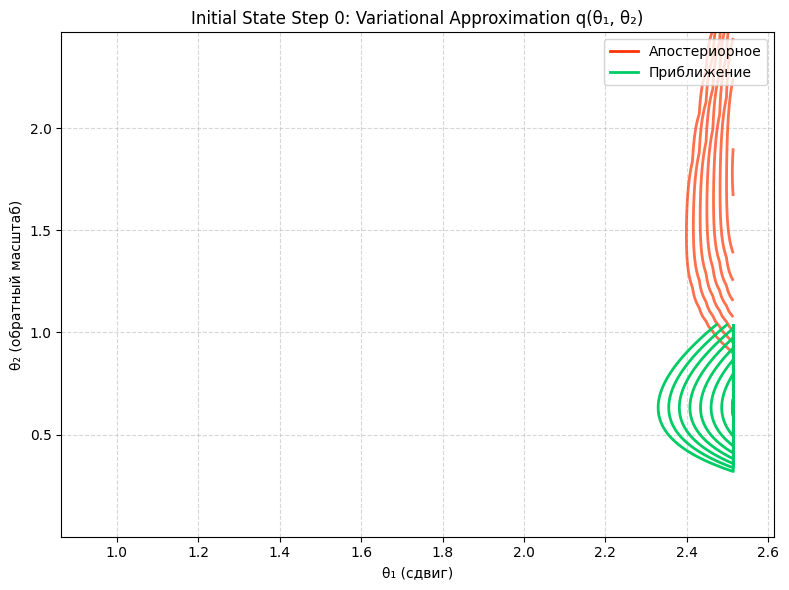

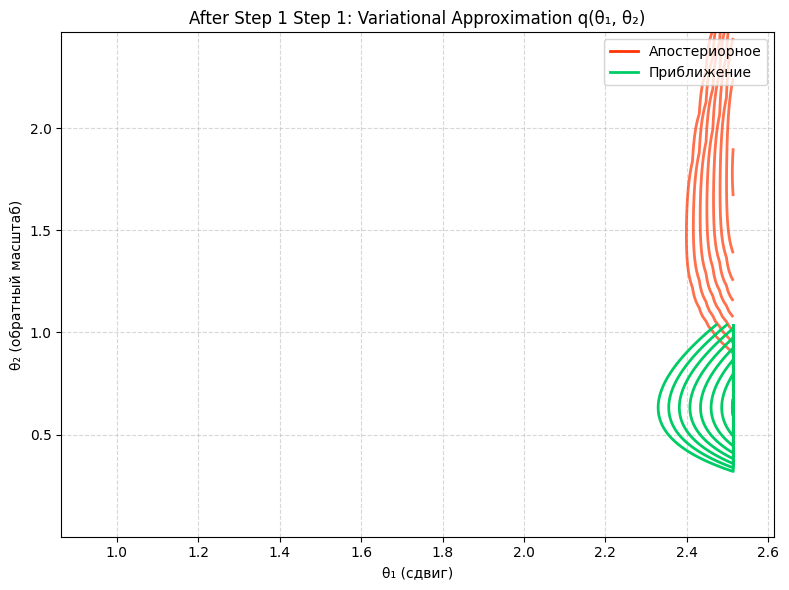

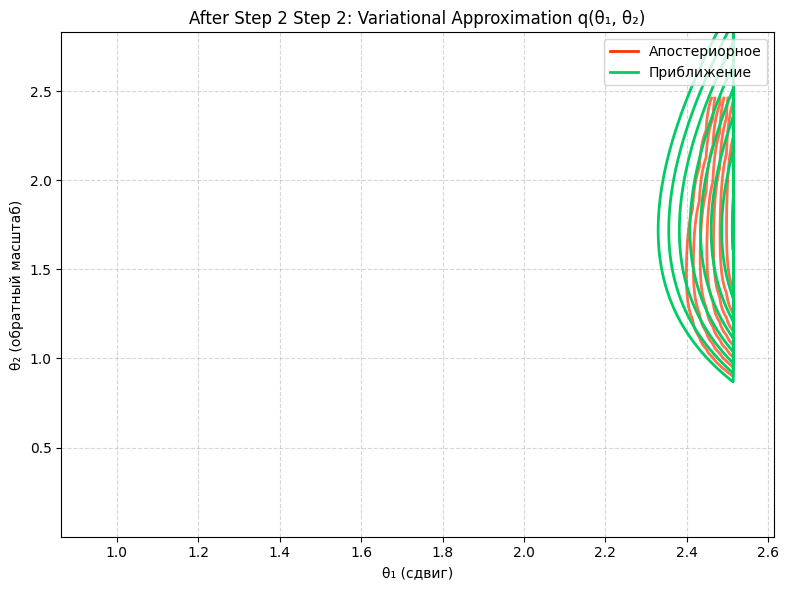

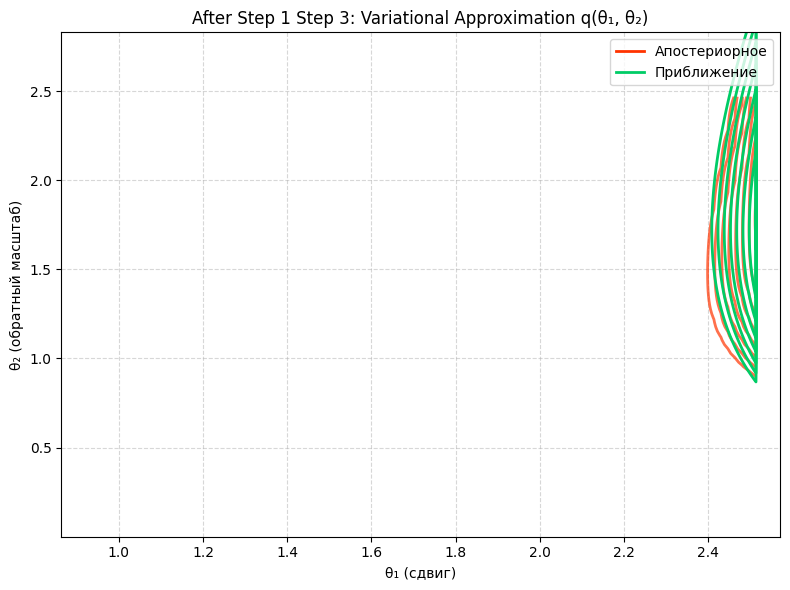

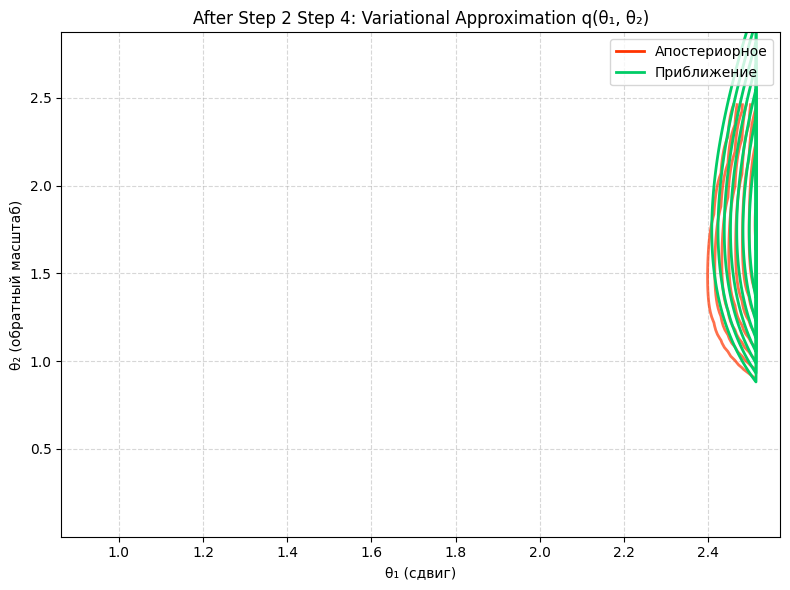

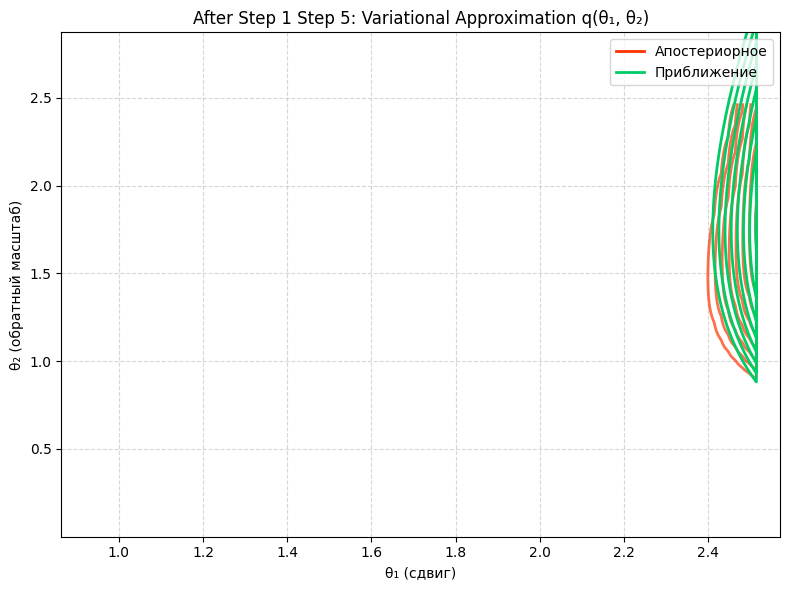

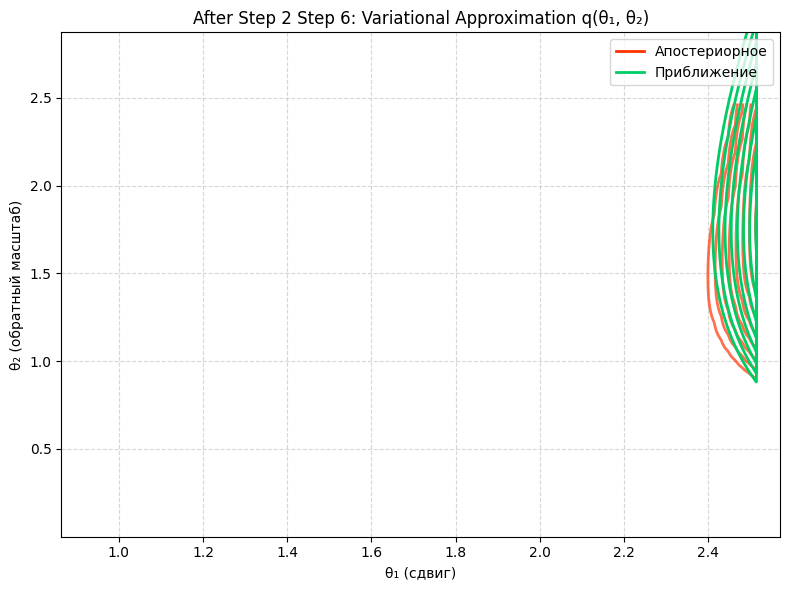

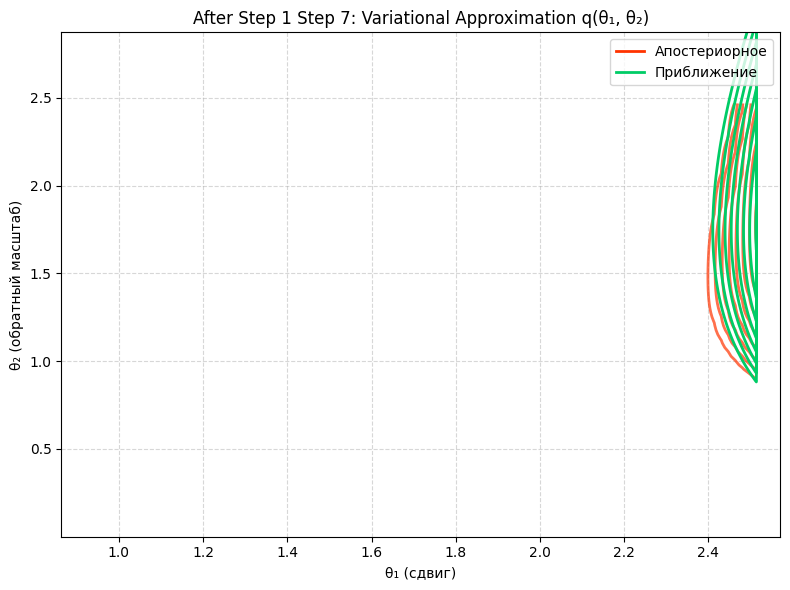

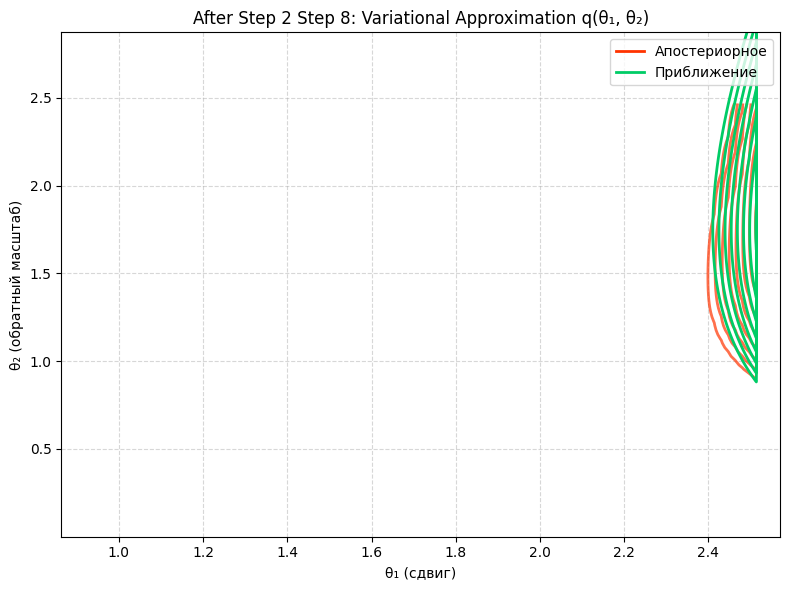

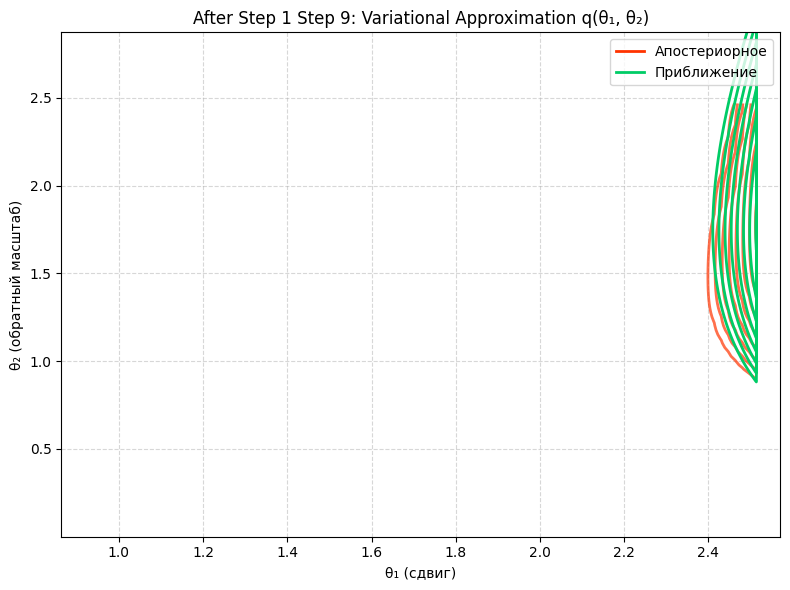

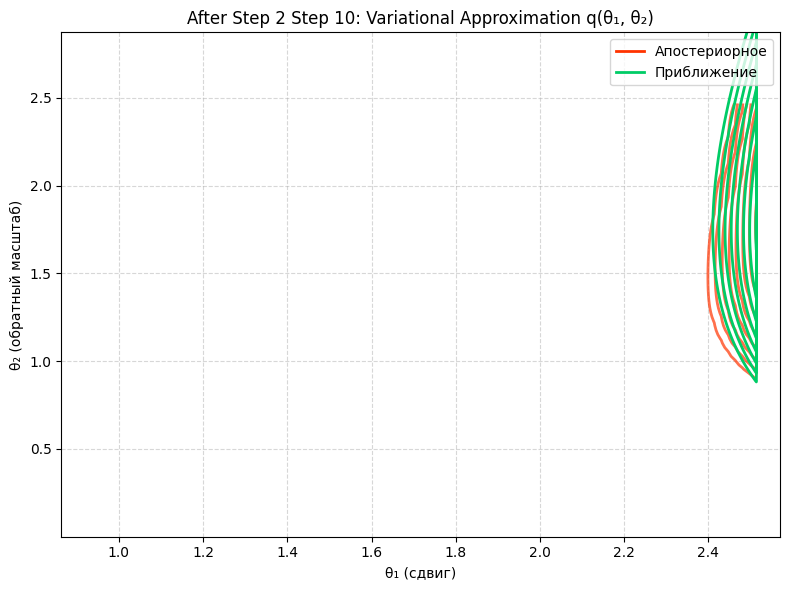

✅ Сошлось на итерации 4

Оценки после обучения:
  E[θ₁] = 2.5026  (истина: 2.5)
  E[θ₂] = 1.7815  (истина: 1.5)
  ELBO на последней итерации: -25.6520


In [273]:
model = MyExponentialVB(X,n=len(X), plot_contour_steps=True)
L_final, q1, q2, elbo_hist, t1_hist, t2_hist = model.fit(tol=1e-8, max_iter=10)

theta1_est = model.E_theta1
theta2_est = model.E_theta2

print(f"\nОценки после обучения:")
print(f"  E[θ₁] = {theta1_est:.4f}  (истина: {theta1_true})")
print(f"  E[θ₂] = {theta2_est:.4f}  (истина: {theta2_true})")
print(f"  ELBO на последней итерации: {L_final:.4f}")

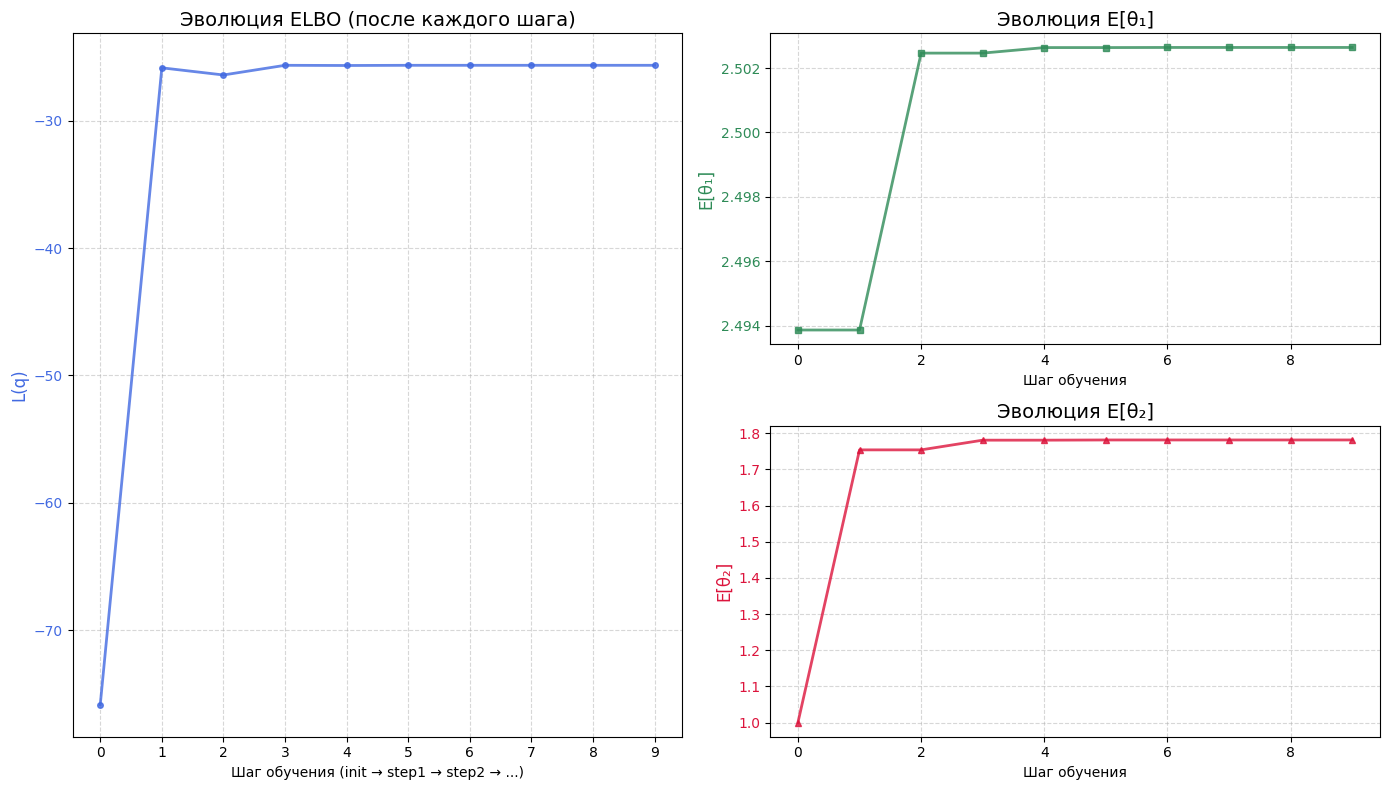

In [275]:
model.plot_final_history()

**Выводы:**

Вновь используя байсовский вывод, нам удалось получить адекватные оценки на параметры, а также апостериорное распределение.

Мы во второй раз подтвердили, что функцию ELBO не убывает.